In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Tweets.csv')
print(df.head())
print("tail")
print(df.tail())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment  
0  I`d have responded, if I were going   neutral  
1                             Sooo SAD  negative  
2                          bullying me  negative  
3                       leave me alone  negative  
4                        Sons of ****,  negative  
tail
           textID                                               text  \
27476  4eac33d1c0   wish we could come see u on Denver  husband l...   
27477  4f4c4fc327   I`ve wondered about rake to.  The client has ...   
27478  f67aae2310   Yay good for both of you. Enjoy the break - 

In [3]:
print(df.isnull().sum())

textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


In [4]:
df.dropna(inplace=True)

In [5]:
print(df.isnull().sum())

textID           0
text             0
selected_text    0
sentiment        0
dtype: int64


In [6]:
import nltk
import re

In [7]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    text = " ".join(words)
    return text

In [11]:
df["text"] = df["text"].apply(clean_text)

In [12]:
print(df["text"].head())

0                          id responded going
1                     sooo sad miss san diego
2                               boss bullying
3                       interview leave alone
4    sons couldnt put releases already bought
Name: text, dtype: object


In [13]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [14]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [stemmer.stem(word) for word in words]
    text = " ".join(words)
    return text

In [15]:
from tqdm import notebook
notebook.tqdm.pandas()

In [17]:
df["text"] = df["text"].progress_apply(clean_text)

  0%|          | 0/27480 [00:00<?, ?it/s]

In [19]:
print(df["text"].head())

0                            id respond go
1                  sooo sad miss san diego
2                               boss bulli
3                      interview leav alon
4    son couldnt put releas alreadi bought
Name: text, dtype: object


In [21]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
print(vectorizer.get_feature_names_out())
print(X.shape)

['aa' 'aaa' 'aaaa' ... 'zzzzi' 'zzzzzzzgoodnight' 'zzzzzzzzzzzzzzz']
(27480, 22724)


In [25]:
y = df["sentiment"]

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [29]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6834061135371179


In [38]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.65      0.59      0.62      1572
     neutral       0.62      0.66      0.64      2236
    positive       0.71      0.71      0.71      1688

    accuracy                           0.66      5496
   macro avg       0.66      0.65      0.66      5496
weighted avg       0.66      0.66      0.66      5496



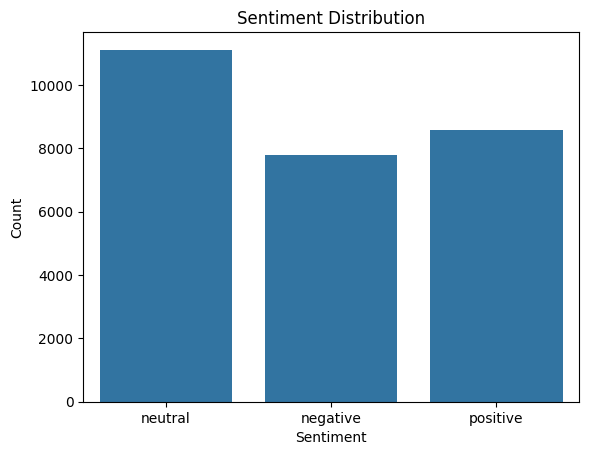

In [39]:
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

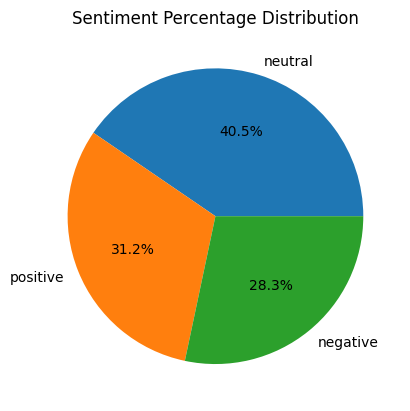

In [40]:
sentiment_counts = df['sentiment'].value_counts()
plt.pie(sentiment_counts,labels=sentiment_counts.index,autopct='%1.1f%%')
plt.title("Sentiment Percentage Distribution")
plt.show()

In [42]:
comparison = pd.DataFrame({'Actual': y_test,'Predicted': y_pred})
print(comparison.head())

         Actual Predicted
1589   positive  positive
10414  negative   neutral
6562    neutral   neutral
2603   positive  positive
4004    neutral   neutral


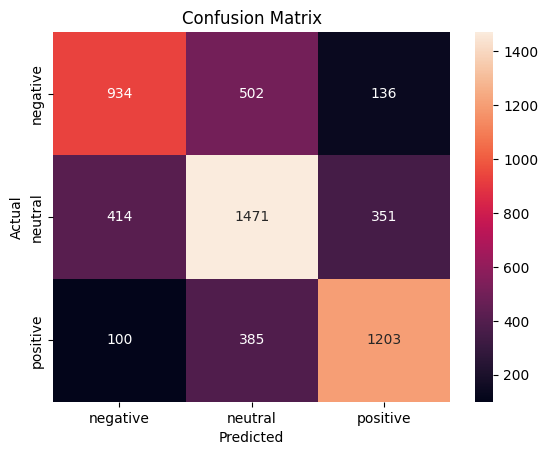

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True,fmt='d',xticklabels=model.classes_,yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()